<a href="https://www.kaggle.com/code/kurtdynguyen/thay-th-focal-tversky-loss?scriptVersionId=355721418" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

Import thư viện

In [1]:
from pathlib import Path
import numpy as np
import random
import cv2
cv2.utils.logging.setLogLevel(cv2.utils.logging.LOG_LEVEL_ERROR)

from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

torch.manual_seed(0)
random.seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


Tìm các cặp ảnh - mask

In [2]:
IMG_EXTS  = {".tif", ".tiff", ".png", ".jpg", ".jpeg"}
MASK_EXTS = {".tif", ".tiff", ".png"}

def index_dir(d: Path, exts):
    idx = {}
    for p in sorted(d.iterdir()):
        if p.suffix.lower() in exts:
            if p.stem in idx:
                print(f"[warn] duplicate stem '{p.stem}' in {d}: {idx[p.stem].name} vs {p.name}")
            else:
                idx[p.stem] = p
    return idx

def find_pairs(img_dir: Path, mask_dir: Path):
    if not img_dir.is_dir() or not mask_dir.is_dir():
        return []
    imgs, masks = index_dir(img_dir, IMG_EXTS), index_dir(mask_dir, MASK_EXTS)
    return [(imgs[s], masks[s]) for s in imgs if s in masks]

In [3]:
DATA_ROOT = Path("/kaggle/input/datasets/kurtdynguyen/gelgenies-segmented-gel-electrophoresis-images")
PARTITION_DATASETS = ["matthew_gels", "matthew_gels_2", "nathan_gels", "quantitation_ladder_gels", "stella_gels_for_finetuning",]
NO_PARTITION_DATASETS = ["external_gels"]

train_pairs, val_pairs, test_pairs = [], [], []

for ds in PARTITION_DATASETS:
    root = DATA_ROOT/ds
    train_pairs += find_pairs(root/"images", root/"masks")
    val_pairs += find_pairs(root/"val_images", root/"val_masks")
    test_pairs += find_pairs(root/"test_images", root/"test_masks")

for ds in NO_PARTITION_DATASETS:
    root = DATA_ROOT/ds
    all_pairs = find_pairs(root/"images", root/"masks")
    random.shuffle(all_pairs)
    n = len(all_pairs)
    n_train = int(0.7*n) #tỉ lệ train/val/test sẽ là 7/1.5/1.5
    n_val = int(0.15*n)
    train_pairs += all_pairs[:n_train]
    val_pairs   += all_pairs[n_train:n_train + n_val]
    test_pairs  += all_pairs[n_train + n_val:]

In [4]:
#đọc ảnh dưới dạng 2D float32 thay vì PILLOW do có sự không nhất quán trong PIL mode/endianness
def load_gray_float(path):
    a = cv2.imread(str(path), cv2.IMREAD_UNCHANGED) 
    if a is None: #cv2 imread không đọc được uint32 TIFF, để if đây đề phòng
        a = np.array(Image.open(path)) 
    a = a.astype(np.float32)            # '>u2' -> native float32 happens correctly here
    if a.ndim == 3:                     # RGB(A) -> average; multipage/odd axes -> first plane
        a = a[..., :3].mean(axis=-1)
    return a

class DienDiSegmentationDataset(Dataset):
    def __init__(self, pairs, img_size=256, augment=False, clip_percentiles=(1, 99)):
        self.pairs = pairs
        self.img_size = img_size
        self.augment = augment
        self.clip_percentiles = clip_percentiles  # None để dùng min-max thuần như cũ

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, index):
        img_path, mask_path = self.pairs[index]
        
        image = load_gray_float(img_path)
        image = cv2.resize(image, (self.img_size, self.img_size), interpolation=cv2.INTER_AREA)
        if image.ndim == 3:
            image = image.mean(axis=-1)

        if self.clip_percentiles is not None:
            # chuẩn hóa robust: cắt theo percentile trước khi scale, tránh vài pixel outlier
            # kéo giãn toàn bộ dynamic range (nguyên nhân gây Dice gần 0 ở một số ảnh)
            lo, hi = np.percentile(image, self.clip_percentiles)
            if hi > lo:
                image = np.clip(image, lo, hi)
                image = (image - lo) / (hi - lo)
            else:
                image = np.zeros_like(image)
        else:
            img_min, img_max = image.min(), image.max()
            if img_min < img_max:
                image = (image - img_min) / (img_max - img_min)
            else:
                image = np.zeros_like(image)

        mask = Image.open(mask_path)
        mask = mask.resize((self.img_size, self.img_size), Image.NEAREST)
        mask = np.array(mask)
        if mask.ndim == 3:
            mask = mask[..., 0]
        mask = np.where(mask > 0, 1.0, 0.0).astype(np.float32)

        if self.augment:
            if random.random() < 0.5:
                image = np.fliplr(image).copy()
                mask = np.fliplr(mask).copy()
            if random.random() < 0.5:
                image = np.flipud(image).copy()
                mask = np.flipud(mask).copy()
            k = random.choice([0, 1, 2, 3])
            image = np.rot90(image, k).copy()
            mask = np.rot90(mask, k).copy()

            # tăng cường cường độ (intensity augmentation): mô phỏng biến thiên độ sáng/tương phản/phơi sáng
            # thường gặp giữa các lần chụp gel khác nhau, không áp dụng lên mask vì mask là nhãn nhị phân
            if random.random() < 0.5:
                brightness_delta = random.uniform(-0.10, 0.10)
                image = image + brightness_delta
            if random.random() < 0.5:
                contrast_factor = random.uniform(0.8, 1.2)
                image = (image - 0.5) * contrast_factor + 0.5
            if random.random() < 0.5:
                gamma_factor = random.uniform(0.8, 1.2)
                image = np.clip(image, 0.0, 1.0) ** gamma_factor
            image = np.clip(image, 0.0, 1.0)

        image = image.astype(np.float32)
        image_T = torch.from_numpy(image).unsqueeze(0)
        mask_T = torch.from_numpy(mask).unsqueeze(0)
        return image_T, mask_T

**Cell này phục vụ kiểm tra các ảnh, xem loader có bỏ sót cơ chế nào làm ảnh hỏng không**

In [5]:
"""
import warnings
def noise_score(a):
    # fraction of variance that is pixel-to-pixel jitter; ~1.0 = white noise, small = real image
    d = np.diff(a, axis=1)
    return float(d.var() / (2 * a.var() + 1e-9))

rows = []
for img_path, _ in train_pairs + val_pairs + test_pairs:
    with warnings.catch_warnings(record=True) as w:
        warnings.simplefilter("always")
        pil_img = Image.open(img_path); mode = pil_img.mode
        old = np.array(pil_img.resize((256, 256), Image.BILINEAR), dtype=np.float32)
        if old.ndim == 3: old = old.mean(-1)
    new = cv2.resize(load_gray_float(img_path), (256, 256), interpolation=cv2.INTER_AREA)
    rows.append((img_path.name, mode, noise_score(old), noise_score(new), bool(w)))

bad = [r for r in rows if r[2] > 0.5 or r[3] > 0.5]
print("Modes:", {m: sum(r[1] == m for r in rows) for m in set(r[1] for r in rows)})
print("Noisy with old loader:", [r[0] for r in rows if r[2] > 0.5])
print("Still noisy with new loader:", [r[0] for r in bad if r[3] > 0.5])

"""

'\nimport warnings\ndef noise_score(a):\n    # fraction of variance that is pixel-to-pixel jitter; ~1.0 = white noise, small = real image\n    d = np.diff(a, axis=1)\n    return float(d.var() / (2 * a.var() + 1e-9))\n\nrows = []\nfor img_path, _ in train_pairs + val_pairs + test_pairs:\n    with warnings.catch_warnings(record=True) as w:\n        warnings.simplefilter("always")\n        pil_img = Image.open(img_path); mode = pil_img.mode\n        old = np.array(pil_img.resize((256, 256), Image.BILINEAR), dtype=np.float32)\n        if old.ndim == 3: old = old.mean(-1)\n    new = cv2.resize(load_gray_float(img_path), (256, 256), interpolation=cv2.INTER_AREA)\n    rows.append((img_path.name, mode, noise_score(old), noise_score(new), bool(w)))\n\nbad = [r for r in rows if r[2] > 0.5 or r[3] > 0.5]\nprint("Modes:", {m: sum(r[1] == m for r in rows) for m in set(r[1] for r in rows)})\nprint("Noisy with old loader:", [r[0] for r in rows if r[2] > 0.5])\nprint("Still noisy with new loader:", [r

In [6]:
IMG_SIZE = 512
BATCH_SIZE = 16

train_ds = DienDiSegmentationDataset(train_pairs, img_size=IMG_SIZE, augment=True)
val_ds   = DienDiSegmentationDataset(val_pairs, img_size=IMG_SIZE, augment=False)
test_ds  = DienDiSegmentationDataset(test_pairs, img_size=IMG_SIZE, augment=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds, batch_size=1, shuffle=False, num_workers=0)

Kiểm thử data trước training

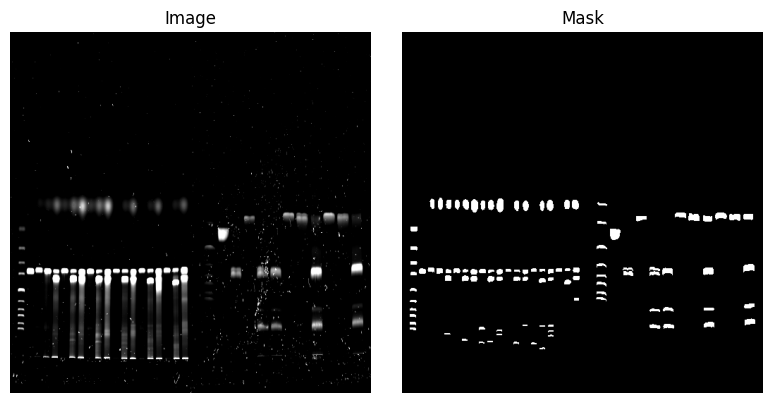

In [7]:
i = random.randint(0, len(train_ds))
img, mask = train_ds[i]

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(img.squeeze(), cmap="gray")
axes[0].set_title("Image")
axes[0].axis("off")
axes[1].imshow(mask.squeeze(), cmap="gray")
axes[1].set_title("Mask")
axes[1].axis("off")
plt.tight_layout()
plt.show()

Model phụ trách segmentation sẽ sử dụng kiến trúc U-Net

In [8]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)
    
class SmallUNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=1, base=16):
        super().__init__()
        self.encoder1 = DoubleConv(in_channels, base)
        self.encoder2 = DoubleConv(base, base*2)
        self.encoder3 = DoubleConv(base*2, base*4)
        self.encoder4 = DoubleConv(base*4, base*8)

        self.pool = nn.MaxPool2d(2)
        self.bottleneck = DoubleConv(base*8, base*16)

        self.up4 = nn.ConvTranspose2d(base*16, base*8, 2, stride=2)
        self.decoder4 = DoubleConv(base*16, base*8)
        self.up3 = nn.ConvTranspose2d(base*8, base*4, 2, stride=2)
        self.decoder3 = DoubleConv(base * 8, base * 4)
        self.up2 = nn.ConvTranspose2d(base*4, base*2, 2, stride=2)
        self.decoder2 = DoubleConv(base*4, base*2)
        self.up1 = nn.ConvTranspose2d(base*2, base, 2, stride=2)
        self.decoder1 = DoubleConv(base*2, base)

        self.out_conv = nn.Conv2d(base, out_channels, 1)

    def forward(self, x):
        e1 = self.encoder1(x)
        e2 = self.encoder2(self.pool(e1))
        e3 = self.encoder3(self.pool(e2))
        e4 = self.encoder4(self.pool(e3))

        b = self.bottleneck(self.pool(e4))

        d4 = self.up4(b)
        d4 = self.decoder4(torch.cat([d4, e4], dim=1))
        d3 = self.up3(d4)
        d3 = self.decoder3(torch.cat([d3, e3], dim=1))
        d2 = self.up2(d3)
        d2 = self.decoder2(torch.cat([d2, e2], dim=1))
        d1 = self.up1(d2)
        d1 = self.decoder1(torch.cat([d1, e1], dim=1))

        return self.out_conv(d1)

Kiến trúc thay thế: Transformer Bottleneck

In [9]:
class TransformerBottleneck(nn.Module):
    def __init__(self, channels, num_layers=4, num_heads=4, mlp_ratio=4.0, dropout=0.1, max_tokens=1024):
        super().__init__()
        self.channels = channels
        # positional embedding học được, đủ lớn cho spatial size lớn nhất có thể gặp
        self.pos_embed = nn.Parameter(torch.zeros(1, max_tokens, channels))
        nn.init.trunc_normal_(self.pos_embed, std=0.02)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=channels,
            nhead=num_heads,
            dim_feedforward=int(channels * mlp_ratio),
            dropout=dropout,
            activation="gelu",
            batch_first=True,
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.norm = nn.LayerNorm(channels)

    def forward(self, x):
        B, C, H, W = x.shape
        tokens = x.flatten(2).transpose(1, 2)  # mỗi pixel của feature map trở thành 1 token

        n_tokens = tokens.size(1)
        tokens = tokens + self.pos_embed[:, :n_tokens, :]

        tokens = self.transformer(tokens)
        tokens = self.norm(tokens)

        out = tokens.transpose(1, 2).view(B, C, H, W)  # đưa về lại dạng feature map
        return out

class SmallUNetTransformer(nn.Module):
    # giống với SmallUNet, khác bottleneck
    def __init__(self, in_channels=1, out_channels=1, base=16, num_layers=4, num_heads=4):
        super().__init__()
        self.encoder1 = DoubleConv(in_channels, base)
        self.encoder2 = DoubleConv(base, base*2)
        self.encoder3 = DoubleConv(base*2, base*4)
        self.encoder4 = DoubleConv(base*4, base*8)

        self.pool = nn.MaxPool2d(2)

        self.bottleneck_proj = DoubleConv(base*8, base*16)
        self.transformer_bottleneck = TransformerBottleneck(
            channels=base*16, num_layers=num_layers, num_heads=num_heads
        )

        self.up4 = nn.ConvTranspose2d(base*16, base*8, 2, stride=2)
        self.decoder4 = DoubleConv(base*16, base*8)
        self.up3 = nn.ConvTranspose2d(base*8, base*4, 2, stride=2)
        self.decoder3 = DoubleConv(base * 8, base * 4)
        self.up2 = nn.ConvTranspose2d(base*4, base*2, 2, stride=2)
        self.decoder2 = DoubleConv(base*4, base*2)
        self.up1 = nn.ConvTranspose2d(base*2, base, 2, stride=2)
        self.decoder1 = DoubleConv(base*2, base)

        self.out_conv = nn.Conv2d(base, out_channels, 1)

    def forward(self, x):
        e1 = self.encoder1(x)
        e2 = self.encoder2(self.pool(e1))
        e3 = self.encoder3(self.pool(e2))
        e4 = self.encoder4(self.pool(e3))

        b = self.bottleneck_proj(self.pool(e4))
        b = self.transformer_bottleneck(b)

        d4 = self.up4(b)
        d4 = self.decoder4(torch.cat([d4, e4], dim=1))
        d3 = self.up3(d4)
        d3 = self.decoder3(torch.cat([d3, e3], dim=1))
        d2 = self.up2(d3)
        d2 = self.decoder2(torch.cat([d2, e2], dim=1))
        d1 = self.up1(d2)
        d1 = self.decoder1(torch.cat([d1, e1], dim=1))

        return self.out_conv(d1)

ARCHITECTURE = "transformer"

ARCHITECTURES = {
    "cnn": lambda: SmallUNet(),
    "transformer": lambda: SmallUNetTransformer(),
}

model = ARCHITECTURES[ARCHITECTURE]().to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f"Đang sử dụng kiến trúc: {ARCHITECTURE}")
print(f"Model has {n_params} parameters")

Đang sử dụng kiến trúc: transformer
Model has 5365457 parameters


Hàm mất mát: mô hình sử dụng hai hàm là BCE và dice loss

In [10]:
def dice_loss(logits, targets, eps=1e-6):
    probs = torch.sigmoid(logits)
    probs = probs.view(probs.size(0), -1)
    targets = targets.view(targets.size(0), -1)
    intersection = (probs * targets).sum(dim=1)
    union = probs.sum(dim=1) + targets.sum(dim=1)
    dice = (2 * intersection + eps) / (union + eps)
    return 1 - dice.mean()

bce_loss_fn = nn.BCEWithLogitsLoss()

def combined_loss(logits, targets):
    return bce_loss_fn(logits, targets) + dice_loss(logits, targets)

#dùng lại hàm dice loss trên, nhưng dùng riêng cho validation set nên không dùng gradient và preds trả về giá trị cứng 0/1
@torch.no_grad()
def dice_coefficient(logits, targets, eps=1e-6):
    preds = (torch.sigmoid(logits) > 0.5).float()
    preds = preds.view(preds.size(0), -1)
    targets = targets.view(targets.size(0), -1)
    intersection = (preds * targets).sum(dim=1)
    union = preds.sum(dim=1) + targets.sum(dim=1)
    dice = (2 * intersection + eps) / (union + eps)
    return dice.mean().item()

Hàm mất mát thay thế: Focal Tversky Loss

Tversky index tổng quát hóa Dice bằng cách cho phép đặt trọng số khác nhau cho False Negative (FN) và False Positive (FP) thông qua alpha, beta. Với alpha > beta (vd 0.7/0.3), mô hình bị phạt nặng hơn khi bỏ sót vùng band (FN) — phù hợp với các band mờ/mảnh dễ bị bỏ sót

In [11]:
def tversky_index(logits, targets, alpha=0.7, beta=0.3, eps=1e-6):
    # alpha: trọng số phạt False Negative (bỏ sót band)
    # beta: trọng số phạt False Positive (nhận nhầm nền thành band)
    probs = torch.sigmoid(logits)
    probs = probs.view(probs.size(0), -1)
    targets = targets.view(targets.size(0), -1)

    TP = (probs * targets).sum(dim=1)
    FP = (probs * (1 - targets)).sum(dim=1)
    FN = ((1 - probs) * targets).sum(dim=1)

    tversky = (TP + eps) / (TP + alpha * FN + beta * FP + eps)
    return tversky

def focal_tversky_loss(logits, targets, alpha=0.7, beta=0.3, gamma=0.75, eps=1e-6):
    # gamma < 1 làm tăng ảnh hưởng của các mẫu khó (tversky thấp) lên loss
    tversky = tversky_index(logits, targets, alpha=alpha, beta=beta, eps=eps)
    loss = torch.pow(1 - tversky, gamma)
    return loss.mean()

def combined_loss_focal_tversky(logits, targets, alpha=0.7, beta=0.3, gamma=0.75):
    return bce_loss_fn(logits, targets) + focal_tversky_loss(logits, targets, alpha=alpha, beta=beta, gamma=gamma)

FT_ALPHA = 0.7
FT_BETA = 0.3
FT_GAMMA = 0.5

LOSS_TYPE = "focal_taversky"

LOSS_FUNCTIONS = {
    "bce_dice": combined_loss,
    "focal_taversky": lambda logits, targets: combined_loss_focal_tversky(
        logits, targets, alpha=FT_ALPHA, beta=FT_BETA, gamma=FT_GAMMA
    ),
}

loss_fn = LOSS_FUNCTIONS[LOSS_TYPE]
print(f"Đang sử dụng: {LOSS_TYPE}" + (f" (alpha={FT_ALPHA}, beta={FT_BETA}, gamma={FT_GAMMA})" if LOSS_TYPE == "focal_taversky" else ""))

Đang sử dụng: focal_taversky (alpha=0.7, beta=0.3, gamma=0.5)


Training

In [12]:
NUM_EPOCHS = 100
LEARNING_RATE = 3e-4  # giảm từ 1e-3, phù hợp hơn với AdamW + scheduler
PATIENCE = 15  # dừng sớm nếu val_dice không cải thiện sau n epoch liên tiếp
SKIP_TRAINING = False  # đổi sang false nếu muốn train lại
CHECKPOINT_PATH = f"best_model_{ARCHITECTURE}_{LOSS_TYPE}_a{FT_ALPHA}_b{FT_BETA}_g{FT_GAMMA}.pt"

if SKIP_TRAINING and Path(CHECKPOINT_PATH).exists():
    model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=device))
    model.eval()
    print(f"Đã tải checkpoint có sẵn: {CHECKPOINT_PATH} — bỏ qua bước training")
else:
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
    # giảm LR khi val_dice ngừng cải thiện (mode="max" vì ta muốn val_dice tăng, không phải giảm)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=5)

    best_dice_score = 0.0
    epochs_without_improvement = 0
    history = {"train_loss": [], "val_dice": [], "lr": []}

    for epoch in range(1, NUM_EPOCHS + 1):
        model.train()
        running_loss = 0.0
        for images, masks in train_loader:
            images, masks = images.to(device), masks.to(device)

            optimizer.zero_grad()
            logits = model(images)
            loss = loss_fn(logits, masks)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)

        train_loss = running_loss / len(train_ds)

        model.eval()
        val_dice_total = 0.0
        with torch.no_grad():
            for images, masks in val_loader:
                images, masks = images.to(device), masks.to(device)
                logits = model(images)
                val_dice_total += dice_coefficient(logits, masks) * images.size(0)
        val_dice = val_dice_total / max(len(val_ds), 1)

        scheduler.step(val_dice)
        current_lr = optimizer.param_groups[0]["lr"]

        history["train_loss"].append(train_loss)
        history["val_dice"].append(val_dice)
        history["lr"].append(current_lr)

        print(f"Epoch {epoch:02d}/{NUM_EPOCHS} | train_loss={train_loss:.4f} | val_dice={val_dice:.4f} | lr={current_lr:.2e}")

        if val_dice > best_dice_score:
            best_dice_score = val_dice
            epochs_without_improvement = 0
            torch.save(model.state_dict(), CHECKPOINT_PATH)
            print(f"\t New best model reached and saved (val_dice={val_dice:.4f})")
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= PATIENCE:
                print(f"Early stopping tại epoch {epoch} (không cải thiện sau {PATIENCE} epoch)")
                break

Epoch 01/100 | train_loss=1.4615 | val_dice=0.4046 | lr=3.00e-04
	 New best model reached and saved (val_dice=0.4046)
Epoch 02/100 | train_loss=1.3553 | val_dice=0.4183 | lr=3.00e-04
	 New best model reached and saved (val_dice=0.4183)
Epoch 03/100 | train_loss=1.3068 | val_dice=0.5878 | lr=3.00e-04
	 New best model reached and saved (val_dice=0.5878)
Epoch 04/100 | train_loss=1.2764 | val_dice=0.6272 | lr=3.00e-04
	 New best model reached and saved (val_dice=0.6272)
Epoch 05/100 | train_loss=1.2511 | val_dice=0.5825 | lr=3.00e-04
Epoch 06/100 | train_loss=1.2259 | val_dice=0.6090 | lr=3.00e-04
Epoch 07/100 | train_loss=1.2029 | val_dice=0.6368 | lr=3.00e-04
	 New best model reached and saved (val_dice=0.6368)
Epoch 08/100 | train_loss=1.1820 | val_dice=0.5319 | lr=3.00e-04
Epoch 09/100 | train_loss=1.1612 | val_dice=0.6460 | lr=3.00e-04
	 New best model reached and saved (val_dice=0.6460)
Epoch 10/100 | train_loss=1.1425 | val_dice=0.6343 | lr=3.00e-04
Epoch 11/100 | train_loss=1.1233

Đánh giá trên tập test

In [13]:
model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=device))
model.eval()

test_dice_total = 0.0
with torch.no_grad():
    for images, masks in test_loader:
        images, masks = images.to(device), masks.to(device)
        logits = model(images)
        test_dice_total += dice_coefficient(logits, masks)

test_dice = test_dice_total / max(len(test_ds), 1)
print(f"[{ARCHITECTURE} | {LOSS_TYPE}] Test set average dice coefficient: {test_dice:.4f}")

[transformer | focal_taversky] Test set average dice coefficient: 0.7362


Phân tích chi tiết sau training

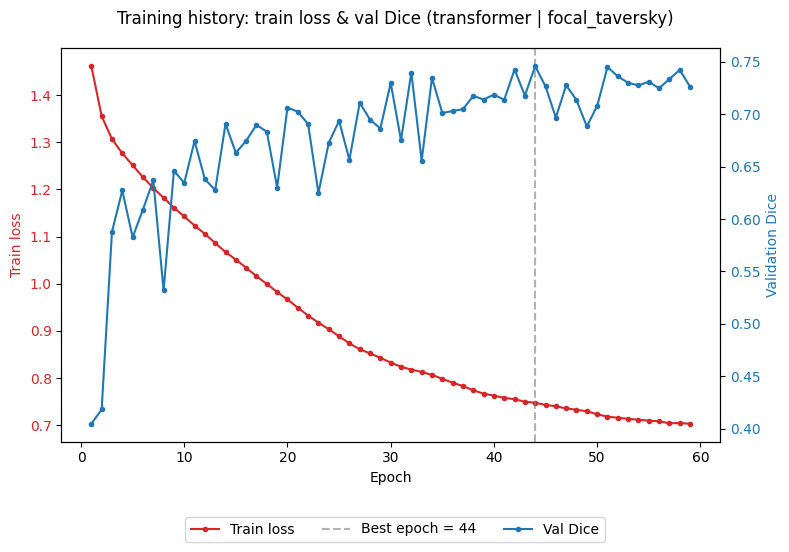

In [14]:
epochs_range = range(1, len(history["train_loss"]) + 1)

fig, ax1 = plt.subplots(figsize=(8, 5))

color_loss = "tab:red"
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Train loss", color=color_loss)
ax1.plot(epochs_range, history["train_loss"], color=color_loss, marker="o", markersize=3, label="Train loss")
ax1.tick_params(axis="y", labelcolor=color_loss)

ax2 = ax1.twinx()
color_dice = "tab:blue"
ax2.set_ylabel("Validation Dice", color=color_dice)
ax2.plot(epochs_range, history["val_dice"], color=color_dice, marker="o", markersize=3, label="Val Dice")
ax2.tick_params(axis="y", labelcolor=color_dice)

best_epoch = int(np.argmax(history["val_dice"])) + 1
ax1.axvline(best_epoch, color="gray", linestyle="--", alpha=0.6, label=f"Best epoch = {best_epoch}")

fig.suptitle(f"Training history: train loss & val Dice ({ARCHITECTURE} | {LOSS_TYPE})")
fig.legend(loc="upper center", bbox_to_anchor=(0.5, -0.02), ncol=3)
plt.tight_layout()
plt.show()

Tính các chỉ số theo từng ảnh (Dice, IoU, Precision, Recall)

In [15]:
@torch.no_grad()
def compute_per_image_metrics(model, loader, eps=1e-6):
    model.eval()
    records = []
    for idx, (images, masks) in enumerate(loader):
        images, masks = images.to(device), masks.to(device)
        probs = torch.sigmoid(model(images))
        preds = (probs > 0.5).float()

        preds_flat = preds.view(preds.size(0), -1)
        masks_flat = masks.view(masks.size(0), -1)

        TP = (preds_flat * masks_flat).sum(dim=1)
        FP = (preds_flat * (1 - masks_flat)).sum(dim=1)
        FN = ((1 - preds_flat) * masks_flat).sum(dim=1)

        dice = (2 * TP + eps) / (2 * TP + FP + FN + eps)
        iou = (TP + eps) / (TP + FP + FN + eps)
        precision = (TP + eps) / (TP + FP + eps)
        recall = (TP + eps) / (TP + FN + eps)

        records.append({
            "index": idx,
            "dice": dice.item(),
            "iou": iou.item(),
            "precision": precision.item(),
            "recall": recall.item(),
        })
    return records

test_metrics = compute_per_image_metrics(model, test_loader)
print(f"Mean Dice: {np.mean([r['dice'] for r in test_metrics]):.4f} | "
      f"Mean IoU: {np.mean([r['iou'] for r in test_metrics]):.4f} | "
      f"Mean Precision: {np.mean([r['precision'] for r in test_metrics]):.4f} | "
      f"Mean Recall: {np.mean([r['recall'] for r in test_metrics]):.4f}")

Mean Dice: 0.7362 | Mean IoU: 0.6036 | Mean Precision: 0.6888 | Mean Recall: 0.8399


Phân bố Dice theo từng ảnh (histogram + boxplot)

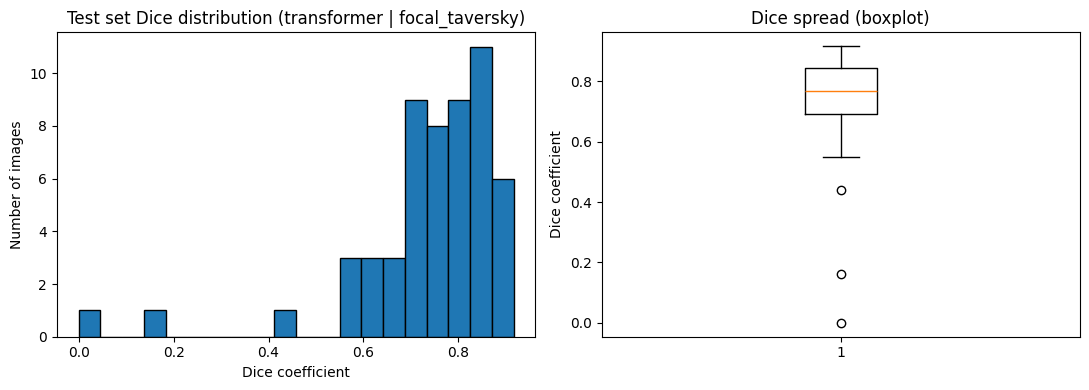

In [16]:
dice_scores = [r["dice"] for r in test_metrics]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(dice_scores, bins=20, color="tab:blue", edgecolor="black")
axes[0].set_xlabel("Dice coefficient")
axes[0].set_ylabel("Number of images")
axes[0].set_title(f"Test set Dice distribution ({ARCHITECTURE} | {LOSS_TYPE})")

axes[1].boxplot(dice_scores, vert=True)
axes[1].set_ylabel("Dice coefficient")
axes[1].set_title("Dice spread (boxplot)")
plt.tight_layout()
plt.show()

So sánh 4 chỉ số cạnh nhau (boxplot)

/tmp/ipykernel_25/3260303747.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=metric_names)


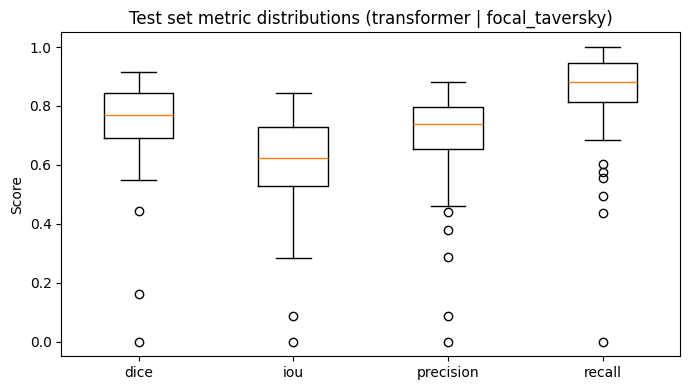

In [17]:
metric_names = ["dice", "iou", "precision", "recall"]
data = [[r[m] for r in test_metrics] for m in metric_names]

fig, ax = plt.subplots(figsize=(7, 4))
ax.boxplot(data, labels=metric_names)
ax.set_title(f"Test set metric distributions ({ARCHITECTURE} | {LOSS_TYPE})")
ax.set_ylabel("Score")
plt.tight_layout()
plt.show()

Dice theo ngưỡng threshold

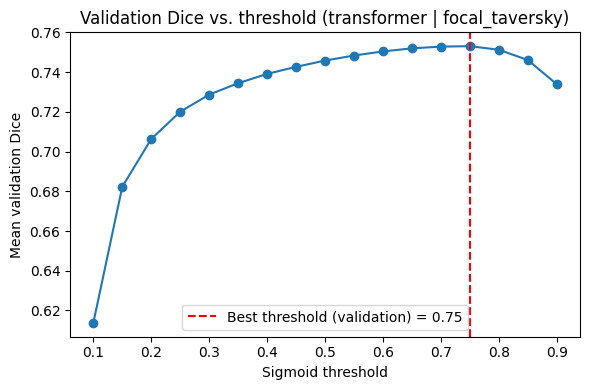

Threshold tối ưu chọn trên validation set: 0.75
[transformer | focal_taversky] Test Dice tại threshold=0.75 (chọn từ validation, không phải test): 0.7444


In [18]:
@torch.no_grad()
def dice_vs_threshold(model, loader, thresholds=np.linspace(0.1, 0.9, 17), eps=1e-6):
    model.eval()
    scores = []
    for t in thresholds:
        dice_total, n = 0.0, 0
        for images, masks in loader:
            images, masks = images.to(device), masks.to(device)
            probs = torch.sigmoid(model(images))
            preds = (probs > t).float()
            preds_flat = preds.view(preds.size(0), -1)
            masks_flat = masks.view(masks.size(0), -1)
            inter = (preds_flat * masks_flat).sum(dim=1)
            union = preds_flat.sum(dim=1) + masks_flat.sum(dim=1)
            dice = (2 * inter + eps) / (union + eps)
            dice_total += dice.sum().item()
            n += images.size(0)
        scores.append(dice_total / n)
    return thresholds, scores

# QUAN TRỌNG: tìm threshold tối ưu trên tập validation, KHÔNG dùng tập test — dùng test để chọn
# threshold rồi báo cáo Dice tại chính threshold đó là một dạng data leakage
thresholds, val_threshold_dice = dice_vs_threshold(model, val_loader)
best_t = thresholds[np.argmax(val_threshold_dice)]

plt.figure(figsize=(6, 4))
plt.plot(thresholds, val_threshold_dice, marker="o")
plt.axvline(best_t, color="red", linestyle="--", label=f"Best threshold (validation) = {best_t:.2f}")
plt.xlabel("Sigmoid threshold")
plt.ylabel("Mean validation Dice")
plt.title(f"Validation Dice vs. threshold ({ARCHITECTURE} | {LOSS_TYPE})")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Threshold tối ưu chọn trên validation set: {best_t:.2f}")

@torch.no_grad()
def evaluate_at_threshold(model, loader, threshold, eps=1e-6):
    model.eval()
    dice_total, n = 0.0, 0
    for images, masks in loader:
        images, masks = images.to(device), masks.to(device)
        probs = torch.sigmoid(model(images))
        preds = (probs > threshold).float()
        preds_flat = preds.view(preds.size(0), -1)
        masks_flat = masks.view(masks.size(0), -1)
        inter = (preds_flat * masks_flat).sum(dim=1)
        union = preds_flat.sum(dim=1) + masks_flat.sum(dim=1)
        dice = (2 * inter + eps) / (union + eps)
        dice_total += dice.sum().item()
        n += images.size(0)
    return dice_total / n

test_dice_at_best_t = evaluate_at_threshold(model, test_loader, best_t)
print(f"[{ARCHITECTURE} | {LOSS_TYPE}] Test Dice tại threshold={best_t:.2f} (chọn từ validation, không phải test): {test_dice_at_best_t:.4f}")

Các ảnh dự đoán tệ nhất (worst-k)

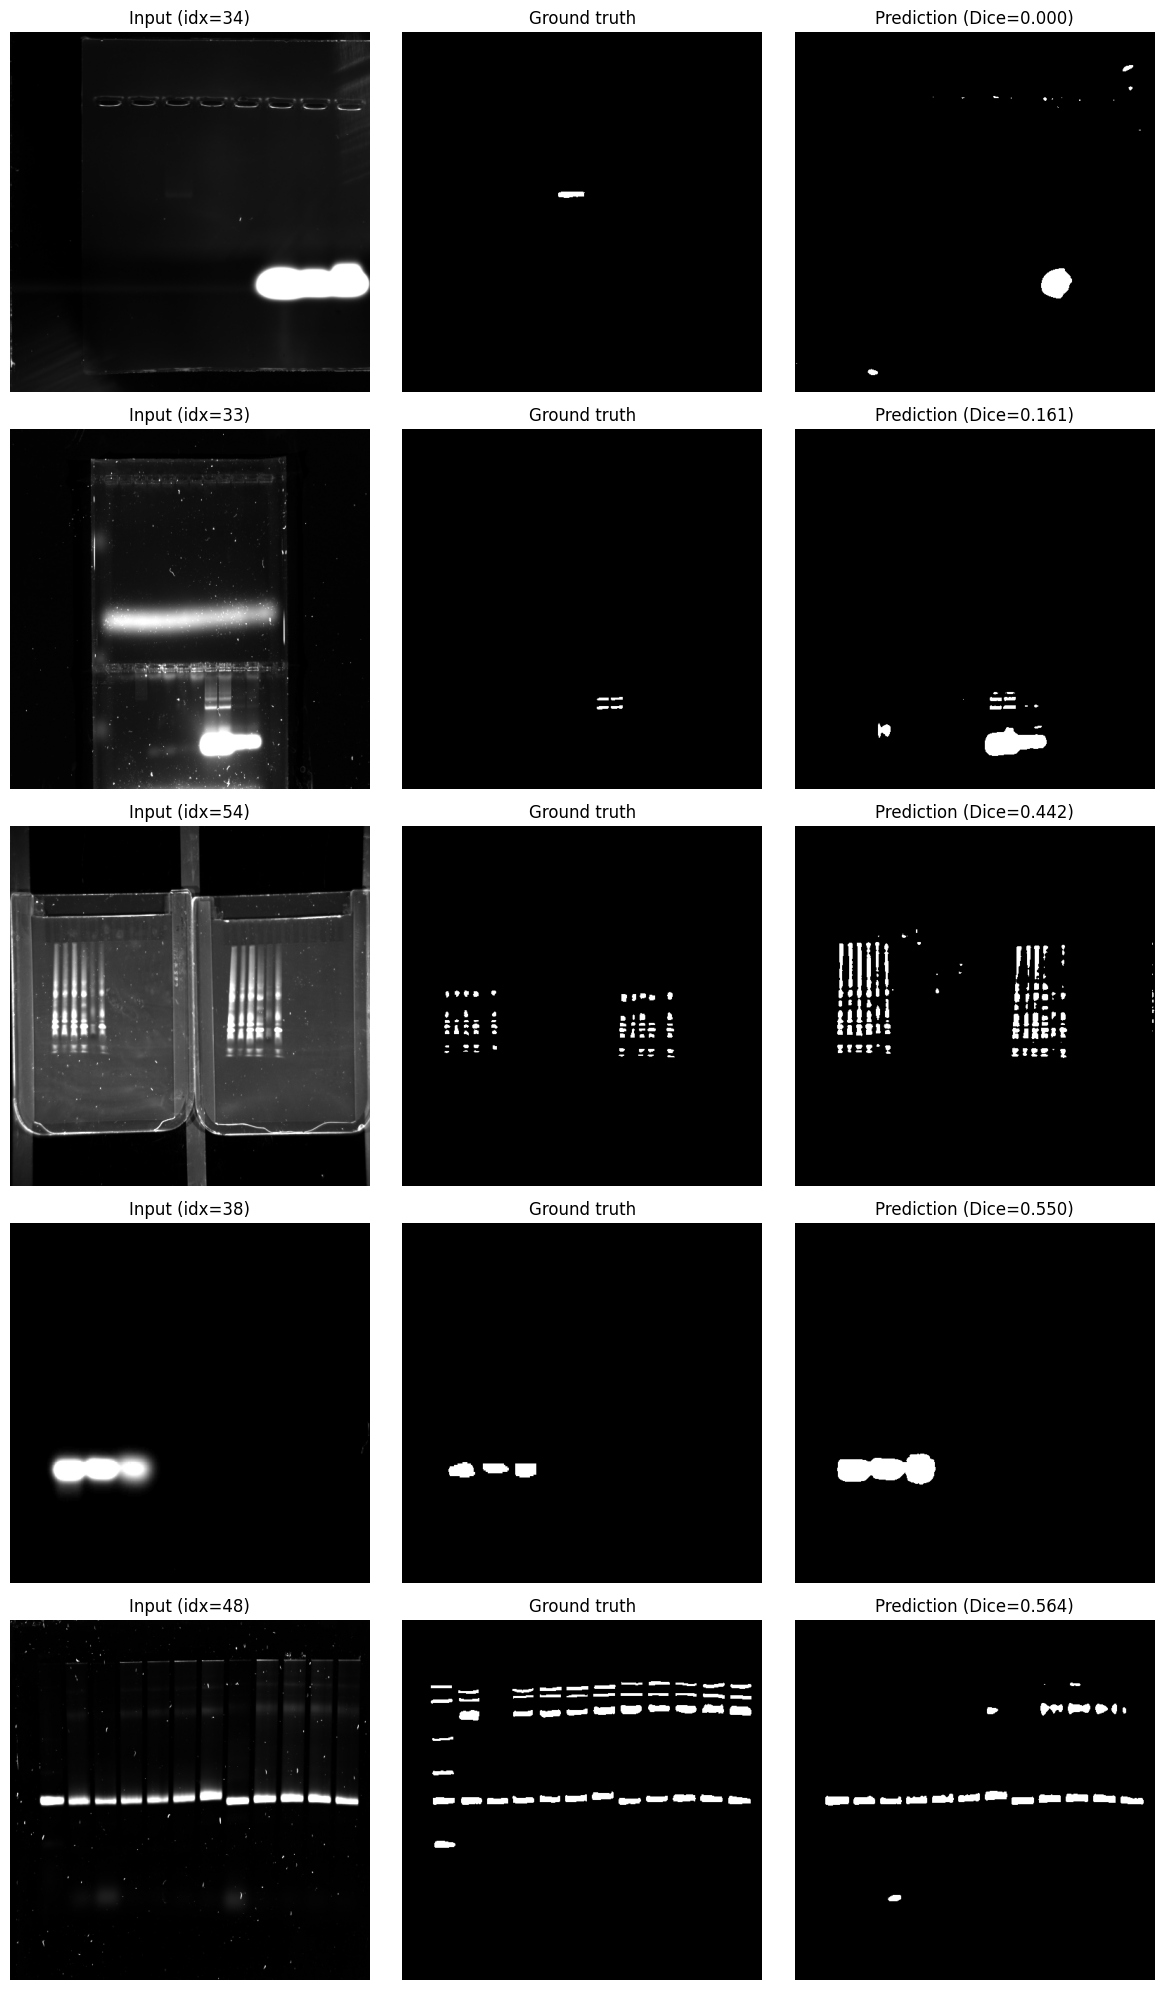

In [19]:
sorted_records = sorted(test_metrics, key=lambda r: r["dice"])
worst_k = sorted_records[:5]

fig, axes = plt.subplots(len(worst_k), 3, figsize=(12, 4 * len(worst_k)))
for row, rec in enumerate(worst_k):
    idx = rec["index"]
    image, mask = test_ds[idx]
    with torch.no_grad():
        logits = model(image.unsqueeze(0).to(device))
        pred = (torch.sigmoid(logits) > 0.5).float().cpu().squeeze()

    axes[row, 0].imshow(image.squeeze(), cmap="gray")
    axes[row, 0].set_title(f"Input (idx={idx})")
    axes[row, 1].imshow(mask.squeeze(), cmap="gray")
    axes[row, 1].set_title("Ground truth")
    axes[row, 2].imshow(pred, cmap="gray")
    axes[row, 2].set_title(f"Prediction (Dice={rec['dice']:.3f})")
    for ax in axes[row]:
        ax.axis("off")

plt.tight_layout()
plt.show()

Lưu kết quả để so sánh giữa các lần chạy

In [20]:
import json as _json

results_to_save = {
    "architecture": ARCHITECTURE,
    "loss_type": LOSS_TYPE,
    "n_params": n_params,
    "history": history,
    "best_val_dice": best_dice_score,
    "test_metrics": test_metrics,
    # Dice tại threshold mặc định 0.5, dùng để so sánh nhất quán giữa các cấu hình
    "test_dice_default_threshold": float(np.mean([r["dice"] for r in test_metrics])),
    # threshold tối ưu chọn trên validation set (không dùng test, tránh rò rỉ thông tin) và Dice tương ứng trên test
    "val_selected_threshold": float(best_t),
    "test_dice_at_val_selected_threshold": float(test_dice_at_best_t),
}
results_path = f"results_{ARCHITECTURE}_{LOSS_TYPE}_a{FT_ALPHA}_b{FT_BETA}_g{FT_GAMMA}.json"
with open(results_path, "w") as f:
    _json.dump(results_to_save, f, indent=2)
print(f"Saved results to {results_path}")
print(f"  test_dice_default_threshold (0.5): {results_to_save['test_dice_default_threshold']:.4f}")
print(f"  val_selected_threshold: {results_to_save['val_selected_threshold']:.2f}")
print(f"  test_dice_at_val_selected_threshold: {results_to_save['test_dice_at_val_selected_threshold']:.4f}")

Saved results to results_transformer_focal_taversky_a0.7_b0.3_g0.5.json
  test_dice_default_threshold (0.5): 0.7362
  val_selected_threshold: 0.75
  test_dice_at_val_selected_threshold: 0.7444
